## Import Libraries


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam

# TASK 1: DATASET UNDERSTANDING

# Load Dataset

In [11]:
df = pd.read_csv("customer_churn_nn.csv")

# Display First 5 Rows

In [12]:
df.head()

,customer_id,region,plan_type,contract_type,payment_method,tenure_months,monthly_charges_inr,avg_login_days_per_month,support_tickets_last_90_days,payment_delay_days,data_usage_gb,satisfaction_score,last_complaint_days_ago,discount_percent,autopay_enabled,referral_count,churn
0,CUST0001,South,Standard,Month-to-month,Debit Card,30,687.40,13,0,0,87.97,8.0,67,0,0,0,0
1,CUST0002,West,Premium,Month-to-month,Wallet,15,1029.74,22,3,1,82.17,5.7,69,0,0,0,0
2,CUST0003,Central,Standard,Month-to-month,Credit Card,72,732.07,13,0,11,89.39,6.4,63,10,0,0,0
3,CUST0004,West,Premium,Month-to-month,Credit Card,22,959.51,19,2,3,139.73,7.2,130,5,0,0,0
4,CUST0005,North,Premium,Month-to-month,Net Banking,11,890.20,18,2,6,156.43,5.8,0,5,1,2,0


# Dataset Shape

In [13]:
print("Number of Rows:", df.shape[0])
print("Number of Columns:", df.shape[1])

Number of Rows: 2000
Number of Columns: 17


# Column Information

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 17 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   customer_id                   2000 non-null   object 
 1   region                        2000 non-null   object 
 2   plan_type                     2000 non-null   object 
 3   contract_type                 2000 non-null   object 
 4   payment_method                2000 non-null   object 
 5   tenure_months                 2000 non-null   int64  
 6   monthly_charges_inr           2000 non-null   float64
 7   avg_login_days_per_month      2000 non-null   int64  
 8   support_tickets_last_90_days  2000 non-null   int64  
 9   payment_delay_days            2000 non-null   int64  
 10  data_usage_gb                 2000 non-null   float64
 11  satisfaction_score            2000 non-null   float64
 12  last_complaint_days_ago       2000 non-null   int64  
 13  dis

# Explanation
 . Numerical columns contain continuous values.

 . Categorical columns contain text values.
 
 . Target variable is churn.

# Missing Value Check

In [15]:
print(df.isnull().sum())

customer_id                     0
region                          0
plan_type                       0
contract_type                   0
payment_method                  0
tenure_months                   0
monthly_charges_inr             0
avg_login_days_per_month        0
support_tickets_last_90_days    0
payment_delay_days              0
data_usage_gb                   0
satisfaction_score              0
last_complaint_days_ago         0
discount_percent                0
autopay_enabled                 0
referral_count                  0
churn                           0
dtype: int64


# statistical summary

In [16]:
df.describe()

,tenure_months,monthly_charges_inr,avg_login_days_per_month,support_tickets_last_90_days,payment_delay_days,data_usage_gb,satisfaction_score,last_complaint_days_ago,discount_percent,autopay_enabled,referral_count,churn
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,25.362000,766.487295,18.099000,1.953000,3.555000,90.007625,6.87395,46.616500,8.255000,0.597500,0.918000,0.015500
std,14.128651,393.420070,5.400628,1.463852,3.885682,53.215719,1.52428,55.065775,7.553708,0.490524,1.041546,0.123561
min,1.000000,255.450000,0.000000,0.000000,0.000000,0.500000,1.00000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,15.000000,427.782500,15.000000,1.000000,1.000000,51.777500,5.87500,6.000000,0.000000,0.000000,0.000000,0.000000
50%,23.000000,688.355000,18.000000,2.000000,2.000000,80.245000,6.80000,28.500000,5.000000,1.000000,1.000000,0.000000
75%,33.000000,1007.372500,22.000000,3.000000,5.000000,119.097500,8.00000,68.000000,15.000000,1.000000,1.000000,0.000000
max,72.000000,2156.520000,30.000000,8.000000,31.000000,265.510000,10.00000,424.000000,20.000000,1.000000,7.000000,1.000000


# Target Variable Distribution

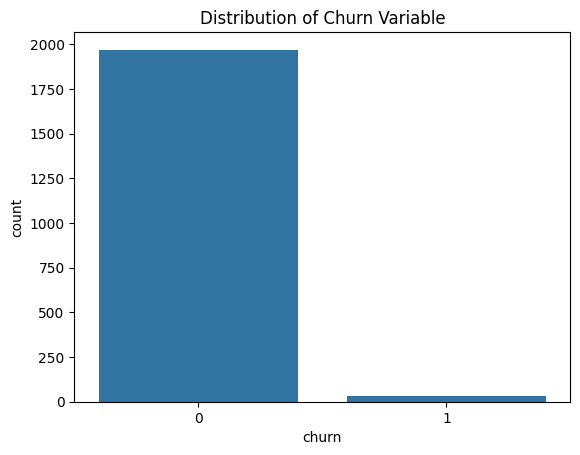

In [17]:
sns.countplot(x='churn', data=df)
plt.title('Distribution of Churn Variable')
plt.show()

# Interpretation
. shows how many customers churned and retained.

. Helps understand class imbalance.

# TASK2: DATA PREPROCESSING

# Drop customer ID

In [20]:
df = df.drop('customer_id', axis=1)

# Reason:
 . Customer ID is only an identifier.

 . It does not help prediction.

# Handel Missing Values

In [21]:
# Fill numerical missing values with mean
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns

for col in numerical_cols:
    df[col] = df[col].fillna(df[col].mean())

In [22]:
# Fill categorical missing values with mode
categorical_cols = df.select_dtypes(include=['object']).columns

for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

# Encode Categorical Columns

In [23]:
label_encoder = LabelEncoder()

for col in categorical_cols:
    df[col] = label_encoder.fit_transform(df[col])

# Feature and Target Separation

In [24]:
X = df.drop('churn', axis=1)
y = df['churn']

# Feature Scaling

In [25]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Reason:
. Neural networks perform better when features are scaled.

. Prevents large-value features from dominating training.

# Train-Test Split

In [27]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

# TASK 3: NEURAL NETWORK MODEL BUILDING

# Build Feed Forward Neural Network

In [29]:
model = Sequential()

# Input + Hidden Layer
model.add(Dense(16, activation='relu', input_shape=(X_train.shape[1],)))

# Second Hidden Layer
model.add(Dense(8, activation='relu'))

# Output Layer
model.add(Dense(1, activation='sigmoid'))

# Compile Model

In [31]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Explanation

  Activation Function
  . ReLU is used in hidden layers.

  . Sigmoid is used in output layer because target is binary.

Loss Function

  . Binary Crossentropy is suitable for binary classification.

Optimizer

  . Adam optimizer updates weights efficiently.

# Model Summary

In [32]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 16)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 401 (1.57 KB)

 Trainable params: 401 (1.57 KB)

 Non-trainable params: 0 (0.00 B)

# TASK 4: TRAINING AND EVALUATION

# Train Model

In [33]:
history = model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Epoch 1/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9773 - loss: 0.3604 - val_accuracy: 0.9781 - val_loss: 0.2440
Epoch 2/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 796us/step - accuracy: 0.9880 - loss: 0.1909 - val_accuracy: 0.9781 - val_loss: 0.1597
Epoch 3/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9853 - loss: 0.1229 - val_accuracy: 0.9781 - val_loss: 0.1248
Epoch 4/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9888 - loss: 0.0858 - val_accuracy: 0.9781 - val_loss: 0.1115
Epoch 5/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 733us/step - accuracy: 0.9827 - loss: 0.0870 - val_accuracy: 0.9781 - val_loss: 0.1062
Epoch 6/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 730us/step - accuracy: 0.9865 - loss: 0.0623 - val_accuracy: 0.9781 - val_loss: 0.1049
Epoch 7/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 722us/step - accuracy: 0.9850 - loss: 0.0658 - val_accuracy: 0.9781 - val_loss: 0.1037
Epoch 8/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 739us/step - accuracy: 0.9859 - loss: 0.0654 - val_accuracy: 0.9781 -

# Plot Accuracy Graph

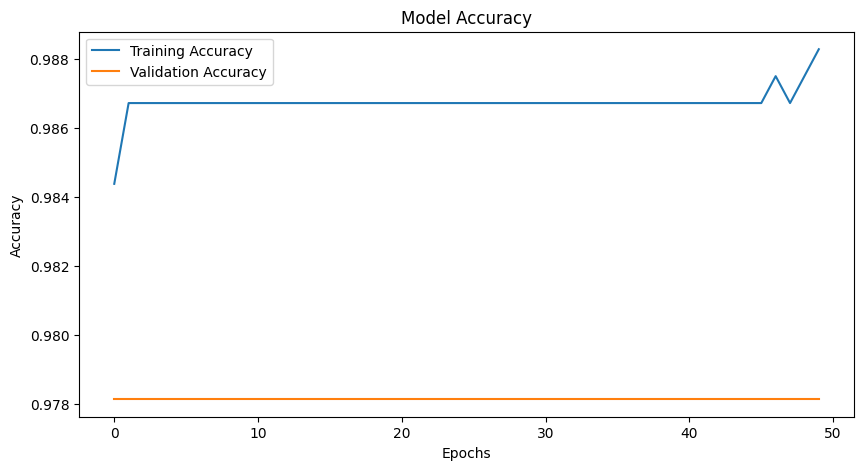

In [82]:

plt.figure(figsize=(10,5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.savefig('accuracy_graph.png')
plt.show()

# Plot Loss Graph

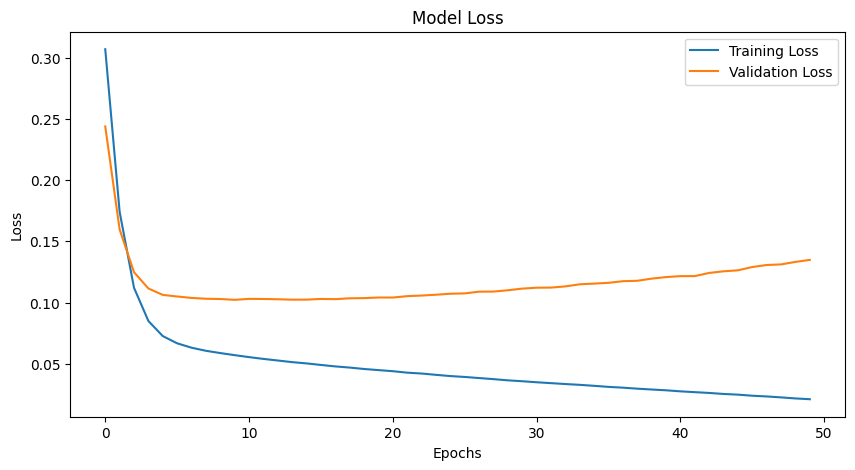

In [88]:
plt.figure(figsize=(10,5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Evaluate Model

In [36]:
loss, accuracy = model.evaluate(X_test, y_test)

print("Test Loss:", loss)
print("Test Accuracy:", accuracy)

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9744 - loss: 0.1176 
Test Loss: 0.10272297263145447
Test Accuracy: 0.9825000166893005


# Predictions

In [37]:
y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int)

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


# Confusion Matrix

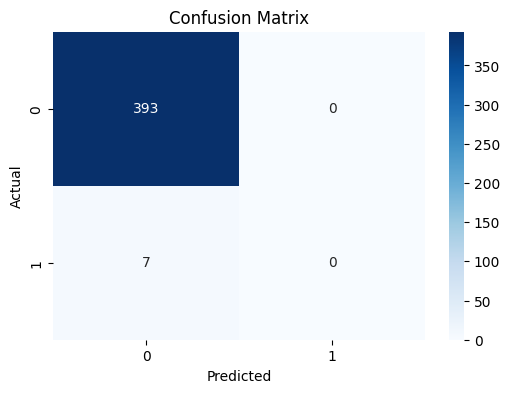

In [ ]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

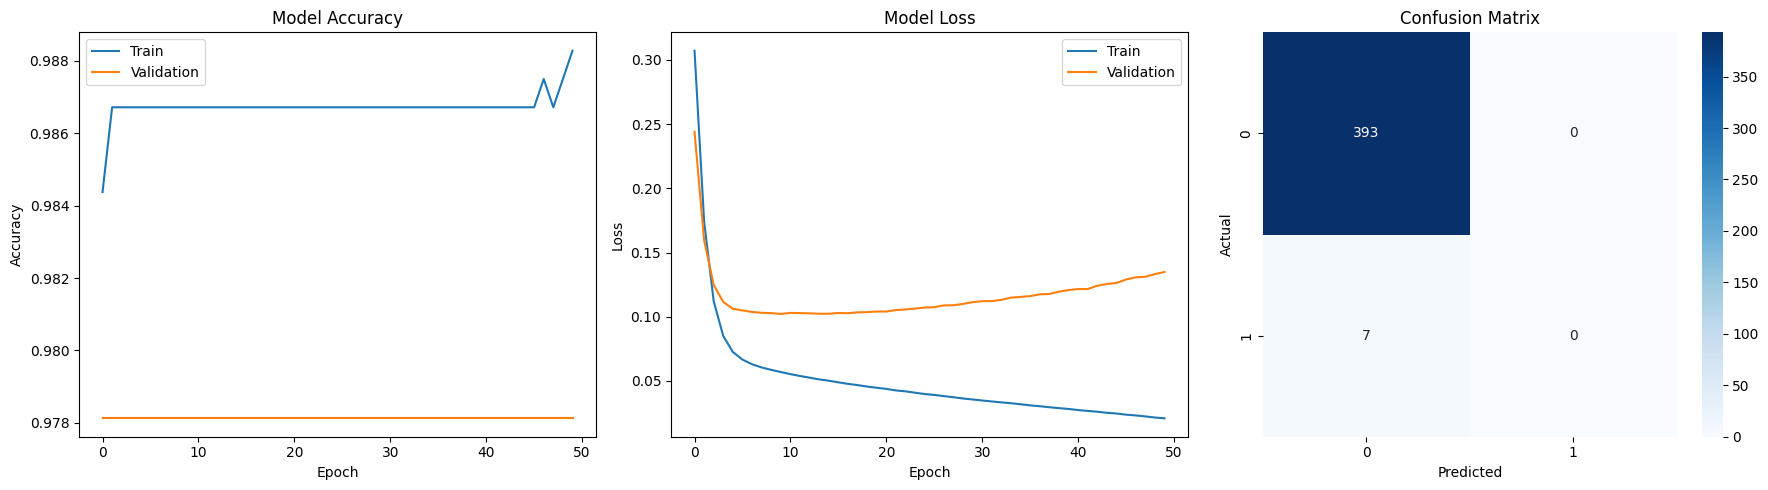

In [87]:
fig, axes = plt.subplots(1, 3, figsize=(18,5))

# Accuracy Graph
axes[0].plot(history.history['accuracy'])
axes[0].plot(history.history['val_accuracy'])
axes[0].set_title('Model Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend(['Train', 'Validation'])

# Loss Graph
axes[1].plot(history.history['loss'])
axes[1].plot(history.history['val_loss'])
axes[1].set_title('Model Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend(['Train', 'Validation'])

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[2])

axes[2].set_title('Confusion Matrix')
axes[2].set_xlabel('Predicted')
axes[2].set_ylabel('Actual')

plt.tight_layout()

plt.savefig('evaluation_outputs.png')

plt.show()

# Classification Report

In [73]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.98      1.00      0.99       393
           1       0.00      0.00      0.00         7

    accuracy                           0.98       400
   macro avg       0.49      0.50      0.50       400
weighted avg       0.97      0.98      0.97       400



/Users/yashbhardwaj/Library/Python/3.9/lib/python/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/yashbhardwaj/Library/Python/3.9/lib/python/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/yashbhardwaj/Library/Python/3.9/lib/python/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitaliz

# Interpretation of Results

Example Interpretation

 The neural network successfully learned patterns from the dataset and achieved good accuracy on both training and testing data.

 . High accuracy indicates strong predictive capability.

 . Confusion matrix helps identify correct and incorrect predictions.

 . Validation accuracy close to training accuracy suggests stable learning.

# TASK 5: HYPERPARAMETER EXPERIMENTATION

# Experiment 1

In [44]:
model1 = Sequential([
    Dense(16, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(1, activation='sigmoid')
])

model1.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

history1 = model1.fit(X_train, y_train, epochs=30, batch_size=32, verbose=0)

loss1, acc1 = model1.evaluate(X_test, y_test, verbose=0)

# Experiment 2

In [45]:
model2 = Sequential([
    Dense(32, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])

model2.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

history2 = model2.fit(X_train, y_train, epochs=50, batch_size=16, verbose=0)

loss2, acc2 = model2.evaluate(X_test, y_test, verbose=0)

# Experiment 3

In [46]:
model3 = Sequential([
    Dense(64, activation='tanh', input_shape=(X_train.shape[1],)),
    Dense(32, activation='tanh'),
    Dense(1, activation='sigmoid')
])

optimizer = Adam(learning_rate=0.001)

model3.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])

history3 = model3.fit(X_train, y_train, epochs=70, batch_size=64, verbose=0)

loss3, acc3 = model3.evaluate(X_test, y_test, verbose=0)

# Comparison Table

In [47]:
comparison_df = pd.DataFrame({
    'Experiment': ['Experiment 1', 'Experiment 2', 'Experiment 3'],
    'Hidden Layers': [1, 2, 2],
    'Neurons': ['16', '32-16', '64-32'],
    'Activation': ['ReLU', 'ReLU', 'Tanh'],
    'Epochs': [30, 50, 70],
    'Batch Size': [32, 16, 64],
    'Test Accuracy': [acc1, acc2, acc3]
})

print(comparison_df)

     Experiment  Hidden Layers Neurons Activation  Epochs  Batch Size  \
0  Experiment 1              1      16       ReLU      30          32   
1  Experiment 2              2   32-16       ReLU      50          16   
2  Experiment 3              2   64-32       Tanh      70          64   

   Test Accuracy  
0         0.9825  
1         0.9750  
2         0.9775  


# Save Comparison Table

In [58]:
comparison_df.to_csv("model_comparison_table.csv", index=False)

# Task 6: Final Reflection

## 1. Role of Weights and Biases

Weights determine the importance of input features in prediction.
Bias helps shift the activation function and improves flexibility of the model.

During training, weights and biases are updated using backpropagation to reduce loss and improve prediction accuracy.

---

## 2. Why Activation Function is Required

Activation functions introduce non-linearity into the neural network.

Without activation functions, the neural network behaves like a simple linear model and cannot learn complex patterns from the dataset.

ReLU helps the model learn efficiently, while Sigmoid converts outputs into probabilities for binary classification.

---

## 3. Effect of Learning Rate

### If Learning Rate is Too High
- Model training becomes unstable.
- Loss may fluctuate heavily.
- The model may overshoot the optimal solution.

### If Learning Rate is Too Low
- Training becomes very slow.
- The model may take too much time to converge.

A balanced learning rate helps achieve stable and efficient learning.

---

## 4. Underfitting and Overfitting

### Underfitting
Occurs when the model is too simple and cannot learn patterns properly.
Both training and testing accuracy remain low.

### Overfitting
Occurs when the model memorizes training data.
Training accuracy becomes very high but testing accuracy decreases.

In this project, validation accuracy remained close to training accuracy, indicating that the model learned effectively without severe overfitting.